# Ансамблевое обучение

Сегодня мы поговорим о том, как можно объединять модели машинного обучения так, чтобы получить результаты лучше чем у каждой из моделей по отдельности. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
import scipy

## Комитет

Самый простой метод объединения моделей $-$ усреднить их результаты (для регрессии) или устроить голосование (для классификации). 

Пусть у нас есть набор моделей $M_1, \dots, M_K$ тогда мы можем агрегировать их результаты:

- Для регрессии мы просто усредняем предсказания моделей:
    $$M(\overline{x})=\sum_{k=1}^{K}w_kM_k(\overline{x}),$$
    где $w_k$ $-$ веса моделей. Необходимо выполнение $\sum w_k=1$.


- Для классификации есть два варианта голосования:
    - Жёсткое голосование (hard voting). Итог выбирается по большинству голосов. 
    $$M(\overline{x})=\arg\max_c\sum_{k=1}^{K}w_k\mathbb{I}[M_k(\overline{x})=c].$$


    - Мягкое голосование (soft voting). Применяется когда базовые модели умеют предсказывать вероятности. Учитывает степень уверенности моделей в предсказаниях.
    $$M(\overline{x})=\arg\max_c\sum_{k=1}^K w_kM(y=c|\overline{x}) $$
    
    
    Мягкое голосование обычно даёт лучшее качество, если модели корректно предсказывают вероятности.

Есть теоретический результат, показывающий, что комитет с равномерными весами будет иметь ошибку не хуже средней ошибки составляющих комитета.

Библиотека sci-kit learn предоставляет инструменты для создания ансамблей такого вида. Классы `VotingClassifier` и `VotingRegressor` предоставляют удобную обёртку для проведения голосования в задачах регрессии и классификации (поддерживается жёсткое и мягкое голосование).

Загрузим набор данных Ирисов Фишера и обучим заведомо слабые модели, чтобы продемонстрировать возможности ансамблей:

In [5]:
from sklearn.ensemble import VotingClassifier, VotingRegressor

df = pd.read_csv("/home/ivanbalashov/LearningMachine/six/Iris.csv", index_col="Id")

m1 = LogisticRegression(C=0.001)
m2 = DecisionTreeClassifier(max_depth=2)
m3 = KNeighborsClassifier(n_neighbors=1)

base_models = [
    ("Logistic Regression", m1),
    ("Decision Tree", m2),
    ("knn", m3)]

model = VotingClassifier(estimators=base_models, voting="hard")

X = df.drop(columns=["Species","PetalLengthCm", "PetalWidthCm"])
Y = df["Species"]

cv_rez = cross_val_score(model, X, Y, scoring="accuracy")
print("Hard voting", f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")

for name, base_model in base_models:
    cv_rez = cross_val_score(base_model, X, Y, scoring="accuracy")
    print(name, f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")
    

Hard voting Accuracy: 0.74 (+- 0.057)
Logistic Regression Accuracy: 0.69 (+- 0.053)
Decision Tree Accuracy: 0.72 (+- 0.045)
knn Accuracy: 0.73 (+- 0.070)


Ми видим следующий результат: каждая из моделей по отдельности давала результат хуже, чем их ансамбль.

Правда набор данных Ирисов Фишера довольно простой, каждая из этих моделей могла бы справиться по одиночке, если бы они специально не были обучены плохо. 

Вынести отсюда мы должны следующую мысль: можно попробовать обучить большое количество простых моделей и попытаться объединить их так, чтобы результаты значительно улучшались.

## Блендинг

Идея состоит в том, чтобы сначала обучить модели предсказывать целевую переменную, а потом использовать предсказания этих моделей как признаки для обучения мета-модели.

Если в качестве мета-модели взять линейную регрессию, то получиться комитет с обучаемыми весами голосования. Но мы не ограничены в выборе мета-модели. Также мета-модель может принимать на вход комбинацию обычных признаков вместе с выходами моделей.

Иногда в литературе данный метод построения ансамблей также называют **стекингом**.

Давайте попробуем применить блендинг на всё том же наборе ирисов фишера.

In [6]:
from sklearn.ensemble import StackingClassifier

m1 = LogisticRegression(C=0.001)
m2 = LinearDiscriminantAnalysis()
m3 = QuadraticDiscriminantAnalysis()

base_models = [
("Logistic Regression", m1),
("LDA", m2),
("QDA", m3)]

model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

cv_rez = cross_val_score(model, X, Y, scoring="accuracy")
print("Blending", f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")
for name, base_model in base_models:
    cv_rez = cross_val_score(base_model, X, Y, scoring="accuracy")
    print(name, f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")

Blending Accuracy: 0.81 (+- 0.065)
Logistic Regression Accuracy: 0.69 (+- 0.053)
LDA Accuracy: 0.81 (+- 0.061)
QDA Accuracy: 0.79 (+- 0.062)


## Смесь экспертов (Mixture of Experts)

В ансамбле **смесь экспертов** снова есть множество разных моделей. И есть главная модель-роутер, которая выбирает то, какая модель будет давать предсказания. 

Этот подход можно применить если вы знаете, что для разных входов могут существовать совершенно разные зависимости целевой переменной от входов. 

К примеру у вас есть разные модели для перевода текстов с разных языков на русский. Но чтобы применить одну из таких моделей необходимо сначала определить какой язык на входе. 

А мы приведём более простой пример. Пусть в какой-то момент угол наклона прямой регрессии резко изменится с разрывом. 

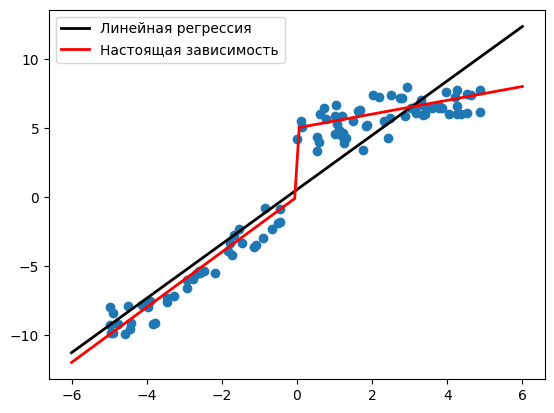

In [7]:
def fun(x): 
    a = x < 0 
    return a * x * 2 + (1 - a) * (x * 0.5 + 5)

def generate_samples(function, n_samples, x_min=0, x_max=10, sigma=1):
    """Генерирует одномерные данные с заданной зависимостью"""
    x = np.random.uniform(x_min, x_max, n_samples)
    y = function(x) + np.random.normal(0, sigma, n_samples)
    return x, y

relation = lambda x: fun(x)

X, y = generate_samples(relation, 100, x_min=-5, x_max=5, sigma=1)

model = LinearRegression()
model.fit(X[:, None], y)
plt.scatter(X, y)

xx = np.linspace(-6, 6, 100)
plt.plot(xx, model.predict(xx[:, None]), color="black", lw=2, label = "Линейная регрессия")
plt.plot(xx, relation(xx), color="red", lw=2, label="Настоящая зависимость")
plt.legend()

Зная, что в функции происходит разрыв, мы можем написать простой класс, который обучит две отдельные модели линейной регрессии на разных частях данных.

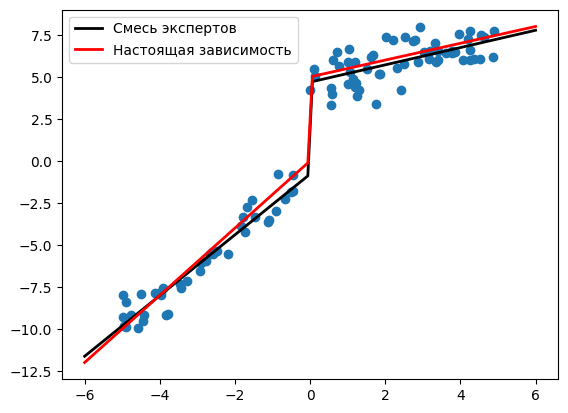

In [8]:
class MakeMixture:
    def __init__(self, change_point=0):
        self.change_point = change_point
        self.model1 = LinearRegression()
        self.model2 = LinearRegression()
        
    def fit(self, x, y):
        mask = x < self.change_point
        self.model1.fit(x[mask].reshape(-1, 1), y[mask])
        mask = x >= self.change_point
        self.model2.fit(x[mask].reshape(-1, 1), y[mask])
        return self
    
    def predict(self, x):
        result = np.zeros(x.shape[0])
        mask = x < self.change_point
        result[mask] = self.model1.predict(x[mask].reshape(-1, 1))
        mask = x >= self.change_point
        result[mask] = self.model2.predict(x[mask].reshape(-1, 1))
        return result

model = MakeMixture(change_point=0)
model.fit(X, y)
plt.scatter(X, y)

xx = np.linspace(-6, 6, 100)
plt.plot(xx, model.predict(xx), color="black", lw=2, label="Смесь экспертов")
plt.plot(xx, relation(xx), color="red", lw=2, label="Настоящая зависимость")
plt.legend()

## Бэггинг

Для понимания Беггинга необходимо вспомнить о разложении ожидаемой ошибки предсказаний (EPE) на три части: **смещение**, **дисперсию** и **шум** (bias-variance-noise).

**Смещение** показывает то, насколько модель промахивается мимо настоящих значений. Если смещение большое, то значит что модель слишком простая и  она не способна описать зависимости в данных.

**Дисперсия** показывает то, насколько сильно меняются предсказания на разных выборках. Слишком большое значение дисперсии значит что модель слишком чувствительна к шуму в данных и такая модель склонна к переобучению.

**Шум** это шум в данных, который невозможно устранить. Причиной могут быть: ошибки измерений, неучтённые факторы.

**Бэггинг** стремится уменьшить дисперсию. Если сгенерировать независимо $k$ выборок, обучить на каждой из них модель, а затем усреднить предсказания, то получится что дисперсия будет в $k$ раз меньше, чем дисперсия каждой отдельной модели.

In [9]:
relation = lambda x: np.sin(x*2)

## X-координаты точек данных
xd = np.array([-3, -2, -1, -0.5, 0, 0.5, 1, 1.5, 2.5, 3, 4]) / 2
num_points = len(xd)

## Для рисования
xs = np.arange(xd[0]-1.5, xd[-1]+1.5, 0.01)

## Выделение полиномиальных признаков
xs_d = np.vstack([xs ** i for i in range(1, num_points+1)]).transpose()
xd_d = np.vstack([xd ** i for i in range(1, num_points+1)]).transpose()

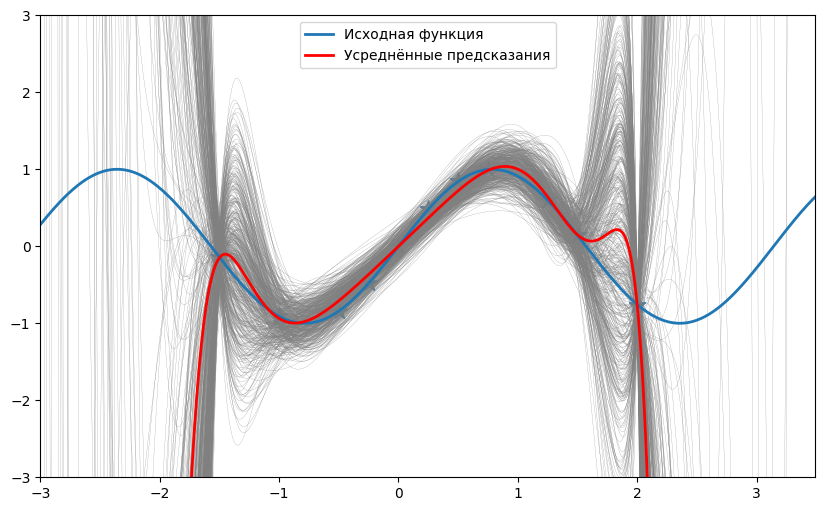

In [10]:
N = 500

## Меняйте alpha для разной регуляризации
alpha =  0.1

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)
ax.set_xlim((xs[0], xs[-1]))
ax.set_ylim((-3, 3))

res = []
for _ in range(N):
    cur_data = relation(xd) + np.random.normal(0, .25, num_points)
    model = Ridge(alpha=alpha)
    model.fit(xd_d, cur_data)
    res.append(model.predict(xs_d))
    ax.plot(xs, res[-1], linewidth=.15, color="0.5")

ax.plot(xs, relation(xs), linewidth=2, label="Исходная функция")
ax.scatter(xd, relation(xd), marker='*', s=150)

ax.plot(xs, np.mean( res, axis=0 ), linewidth=2, label="Усреднённые предсказания", color="red")
ax.legend(loc="upper center")
plt.show()

На примере полиномиальной регрессии видно как отдельны модели могут довольно сильно переобучаться, но при усреднении они могут давать более адекватные предсказания.

In [11]:
def generate_samples(function, n_samples, x_min=0, x_max=10, sigma=1):
    """Генерирует одномерные данные с заданной зависимостью"""
    x = np.random.uniform(x_min, x_max, n_samples)
    y = function(x) + np.random.normal(0, sigma, n_samples)
    return x, y

Далее мы попробуем обучить много решающих деревьев глубины 7 на выборках по 20 элементов.

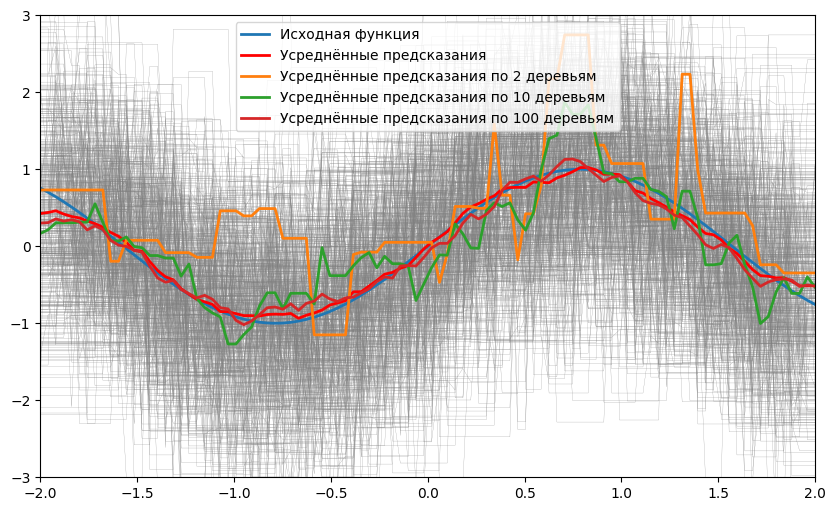

In [12]:
N = 500
xx = np.linspace(-2,2,100)
## Меняйте alpha для разной регуляризации

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)
ax.set_xlim((xx[0], xx[-1]))
ax.set_ylim((-3, 3))

res = []
for _ in range(N):
    X, Y = generate_samples(relation, 20, x_min=-2, x_max=2, sigma=1)
    model = DecisionTreeRegressor(max_depth=7)
    model.fit(X[:, None], Y)
    res.append(model.predict(xx[:,None]))
    ax.plot(xx, res[-1], linewidth=.15, color="0.5")

ax.plot(xx, relation(xx), linewidth=2, label="Исходная функция")

ax.plot(xx, np.mean( res, axis=0 ), linewidth=2, label="Усреднённые предсказания", color="red")
for i in [2, 10, 100]:
    ax.plot(xx, np.mean( res[:i], axis=0 ), linewidth=2, label=f"Усреднённые предсказания по {i} деревьям")
ax.legend(loc="upper center")
plt.show()

Каждое дерево в отдельности довольно плохо описывает исследуемую зависимость, но если усреднить их предсказания, то мы получим что-то очень похожее на настоящую зависимость. 

Отобразим на графике оценку смещения и дисперсии:

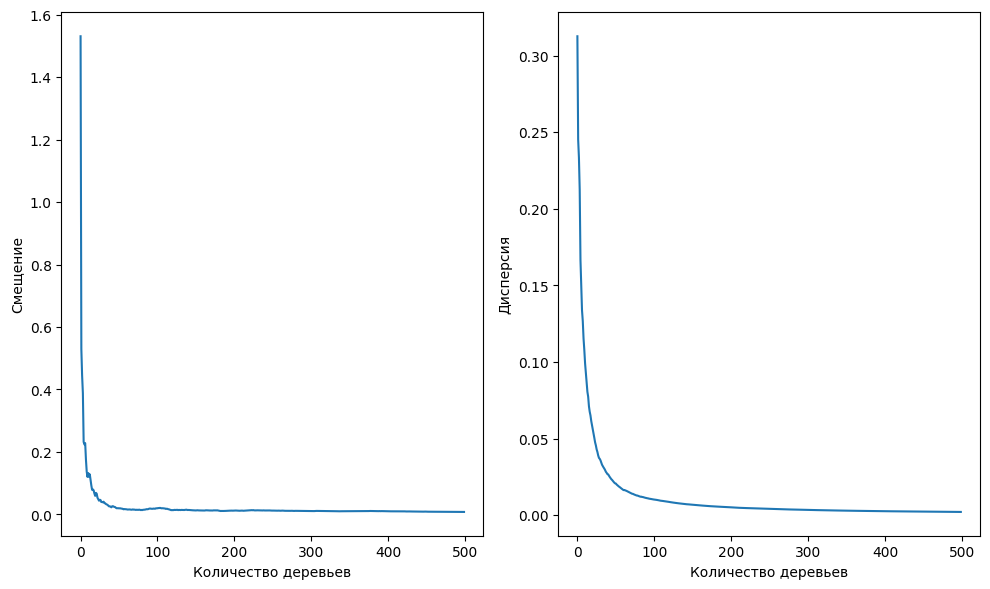

In [13]:
res = np.array(res)
M, N = res.shape
y = relation(xx)  # (N,)

# кумулятивные суммы и суммы квадратов
cum_sum = np.cumsum(res, axis=0)            # (M, N)
mean_cum = cum_sum / (np.arange(1, M+1)[:, None])  # (M, N)

cum_sq = np.cumsum(res**2, axis=0)          # (M, N)
# variance: E[X^2] - (E[X])^2
var_pop = (cum_sq / (np.arange(1, M+1)[:, None])) - mean_cum**2  # (M, N)
var_pop = np.maximum(var_pop, 0.0)  # численно безопасно

k = np.arange(1, M+1)[:, None]  # (M,1)
variance_per_x_for_each_k = var_pop / k  # Var(mean) per x for each k  -> (M,N)
variance = variance_per_x_for_each_k.mean(axis=1)  # (M,)

# bias^2 
bias2 = np.mean((mean_cum - y[None, :])**2, axis=1)  # (M,)

fig, axes = plt.subplots(1,2)
fig.set_size_inches(10,6)
axes[0].plot(bias2)
axes[0].set_xlabel("Количество деревьев")
axes[0].set_ylabel("Смещение")
axes[1].plot(variance[1:])
axes[1].set_xlabel("Количество деревьев")
axes[1].set_ylabel("Дисперсия")
fig.tight_layout()

Теоретический результат говорит нам, что при усреднении предсказаний $k$ базовых моделей дисперсия должна уменьшаться в $k$ раз. На рисунке мы как раз видим график функции, похожей на гиперболу.

Но есть проблема: в реальной жизни мы не можем порождать случайные независимые выборки, нам всегда приходится работать с ограниченным набором данных. Но оказывается, что в этом нет необходимости. Достаточно, чтобы обучаемые модели были в некоторой степени не похожи друг на друга. Тогда при усреднении их предсказаний мы получим  Идея бэггинга развивается в модели **случайный лес** (Random Forest).

### Случайный лес

В качестве базовой модели выступают деревья принятия решений. Для построения очередного дерева выполняются следующие шаги:
- Из общей выборки $X$ генерируется с возвращением (то есть элементы могут повторяться) подвыборка $X'$ того же размера, что и $X$.
- Обучается дерево на подвыборке $X'$.
- При обучении дерева в каждом узле выбирается $n<N$ признаков, где $N$ $-$ полное число признаков, далее среди выбранных признаков находится лучшее разбиение. Этот шаг направлен на то, чтобы сделать базовые модели менее скоррелированными.

Далее предсказания моделей усредняются для получения итоговых предсказаний.

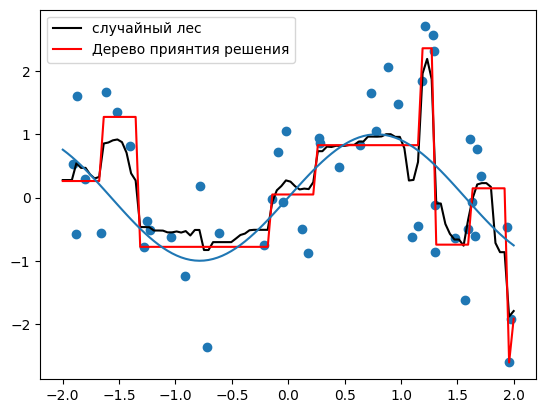

In [14]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

X, Y = generate_samples(relation, 50, x_min=-2, x_max=2, sigma=1)

rf = RandomForestRegressor(n_estimators=100, max_depth=4)
rf.fit(X[:, None], Y)

tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X[:, None], Y)

plt.plot(xx, rf.predict(xx[:,None]), color="black", label="случайный лес")

plt.plot(xx, tree.predict(xx[:,None]), color="red", label="Дерево приянтия решения")
plt.plot(xx, relation(xx))
plt.scatter(X, Y)
plt.legend()

На графике мы видим сильное уменьшение влияния выбросов на получаемые предсказания $-$ это и есть эффект уменьшения **дисперсии** модели. 

Стоит отметить серьёзное ограничение данного метода. Есть теоретический результат, показывающий что бэггинг уменьшает **дисперсию**, случайный лес эту идею развивает и тоже успешно позволяет уменьшать **дисперсию**. Но уменьшения **смещения** данная модель на гарантирует. 

Часто будет оказываться так, что модель случайного леса будет недостаточно выразительной чтобы описать зависимость в данных. Нам потребуется метод, позволяющий уменьшать **смещение**, то есть объединять модели так, чтобы они вместе составляли что-то более выразительное.

# Бустинг

Этот метод построения ансамблей соединяет модели последовательно. Каждая следующая модель пытается исправить ошибку предыдущей модели. Предсказание строится:

$$F_t(x)=F_{t-1}(x)+\alpha_tf_t(x),$$

$F_t$ $-$ новая модель, $F_{t-1}$ $-$ имеющаяся модель (зафиксирована, не изменяется), $f_t$ $-$ обучаемая часть. Коэффициент $\alpha_t$ часто называют темпом обучения (learning rate).

Есть разные методы того, как обучать бустинг. С некоторыми из них мы познакомимся.

## AdaBoost

Этот метод основан на последовательном обучении "слабых" классификаторов. На каждом шаге для точек данных оценивается ошибка и назначается вес значимости. Далее обучаются новые классификаторы на перевзвешенной обучающей выборке. Предсказание получается как взвешенное голосование между обученными моделями.

В качестве базовых моделей для построения такого ансамбля подойдёт любая модель, которая может обучаться на взвешенной выборке, но почти всегда используют деревья принятия решений.

А теперь взглянем на обучение AdaBoost со стороны математики на примере задачи классификации на два класса.

Как обычно у нас имеется набор данных $D=\{(\overline{x}_n,y_n)\}_{n=1}^N, y_n\in\{-1,1\}$. Пусть у нас есть обученный классификатор $f_t$, тогда мы можем посчитать взвешенную ошибку: $\varepsilon_t=\sum_{i=1}^{N}w_i^{(t)}\mathbb{I}[f_t(\overline{x}_i)\neq y_i]$. Алгоритм обучения выглядит следующим образом:

- Инициализация весов объектов в выборке равными значениями: $w_i^{(1)}=\frac{1}{N}$.
- for t=1..N
    - Обучаем $f_t$ на взвешенной выборке с весами $w_i^{(t)}$. Получаем значение $\varepsilon_t$.
    - Вычисляем вес классификатора: $\alpha_t=\frac{1}{2}\log\frac{1-\varepsilon_t}{\varepsilon_t}$.
    - Вычисляем новые веса точек данных: $$w_i^{(t+1)}=\frac{1}{z_t}w_i^{(t)}e^{-\alpha_ty_if_i(\overline{x}_i)},$$
    где $z_t$ $-$ нормировочная константа, чтобы веса суммировались в 1.
- Итоговое предсказание строится как взвешенное голосование: $F(\overline{x})=\text{sign}(\sum_t\alpha_tf_t(\overline
{x}))$.

Есть результат, показывающий то, что если каждый классификатор хоть сколько-то лучше случайного угадывания, то ошибка на обучающей выборке будет убывать экспоненциально. То есть мы можем увеличивать количество моделей в ансамбле и тем самым делать модель всё более выразительной. 

Несложно обобщить описанный алгоритм на случай нескольких классов и на задачу регрессии.

In [15]:
# ! unzip train_cat_in_dat.zip

Мы рассмотрим разные ансамблевые модели на искусственном наборе данных, содержащем большое количество категориальных столбцов.

In [18]:
df = pd.read_csv("/home/ivanbalashov/LearningMachine/eleven/train_cat_in_dat.zip", index_col="id")

print("Количество строк:", len(df))
print("Количество столбцов:", len(df.columns))
df.head()

Количество строк: 300000
Количество столбцов: 24


,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month,target
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,T,Y,Green,Triangle,Snake,Finland,Bassoon,...,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2,0
1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,Piano,...,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8,0
2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,Theremin,...,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2,0
3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,Oboe,...,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1,1
4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,Oboe,...,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8,0


Столбцы *bin* - бинарные, *nom* - категориальные (номинальные), *ord* - порядковые (ординальные).

В данных присутствует дисбаланс классов. Авторы набора данных для оценки качества моделей предлагают вычислять метрику roc_auc для положительного класса.

In [19]:
df["target"].value_counts()

target
0    208236
1     91764
Name: count, dtype: int64

Вычислим количество уникальных значений в каждом столбце:

In [20]:
print("Столбец | Количество уникальных значений")
for col in df.columns:
    print(f"{col:8}| {df[col].nunique()}")

Столбец | Количество уникальных значений
bin_0   | 2
bin_1   | 2
bin_2   | 2
bin_3   | 2
bin_4   | 2
nom_0   | 3
nom_1   | 6
nom_2   | 6
nom_3   | 6
nom_4   | 4
nom_5   | 222
nom_6   | 522
nom_7   | 1220
nom_8   | 2215
nom_9   | 11981
ord_0   | 3
ord_1   | 5
ord_2   | 6
ord_3   | 15
ord_4   | 26
ord_5   | 192
day     | 7
month   | 12
target  | 2


Мы сразу можем заметить следующую проблему: применение one-hot encoding невозможно для столбцов nom_5-nom_9.

Пока мы закодируем числами имеющиеся признаки. Для ординальных признаков соблюдём их порядок. Для столбцов ord_3-ord_5 указано, что их порядок - лексикографический.

In [21]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

# кодируем все столбцы, кроме ординальных, дат и целевой переменной
for_le = set(df.columns) - {"target", "day", "month", "ord_0", "ord_1", "ord_2", "ord_3", "ord_4", "ord_5"}
for col in for_le:
    df[col] = LabelEncoder().fit_transform(df[col])

In [22]:
ord_to_order = {"ord_0": [1, 2 , 3],
                "ord_1": ["Novice", "Contributor", "Expert", "Master", "Grandmaster"],
                "ord_2": ["Freezing", "Cold", "Warm", "Hot", "Boiling Hot", "Lava Hot"]
                }

for col in ["ord_3", "ord_4", "ord_5"]:
    ord_to_order[col] = sorted(list(df[col].value_counts().index))

cols   = list(ord_to_order.keys())
values = list(ord_to_order.values())

df[cols] = OrdinalEncoder(categories=values).fit_transform(df[cols]).astype(int)

In [23]:
df.head()

,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month,target
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,1,1,1,5,5,3,0,...,2175,1,4,1,7,3,136,2,2,0
1,0,1,0,1,1,1,4,3,5,2,...,11635,0,4,3,0,0,93,7,8,0
2,0,0,0,0,1,0,4,4,5,3,...,8078,0,2,5,7,17,31,7,2,0
3,0,1,0,0,1,2,4,5,0,1,...,6056,0,4,4,8,3,134,2,1,1
4,0,0,0,0,0,2,4,4,0,1,...,8231,0,4,0,0,17,158,7,8,0


In [24]:
X = df.drop(columns="target")
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.8, stratify=Y, random_state=43)

Для сравнения применим простую логистическую регрессию:

In [25]:
model = LogisticRegression(solver="newton-cholesky")
# model = LogisticRegression()
model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.7499
test ROC AUC: 0.7502
test Accuracy: 0.7351


Также попробуем применить случайный лес:

In [26]:
model = RandomForestClassifier(max_depth=5, n_estimators=1000, n_jobs=-1)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.7441
test ROC AUC: 0.7360
test Accuracy: 0.7028


B тут можно заметить, что случайный лес не показывает хороших результатов. Он даже хуже логистической регрессии, которая строит линейные разделяющие поверхности. Выразительности случайного леса тут недостаточно.

А далее попробуем обучить AdaBoost. У самого AdaBoost параметров немного: 
- `n_estimators` $-$ количество моделей в ансамбле.
- `learning_rate` $-$ темп обучения, модификатор веса вклада каждой модели в предсказания ансамбля.

Основной подбор параметров имеет смысл производить среди параметров базовых моделей. По умолчанию за базовую модель выбираются деревья принятия решений глубины 1.

In [27]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier()

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.7527
test ROC AUC: 0.7514
test Accuracy: 0.7361


Можно сразу заметить: обучение бустинга это трудоёмкий процесс. 

Нам удалось сделать результаты лучше чем у логистической регрессии. Давайте попробуем обучить гиперпараметры.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

In [29]:
param_dist = {
    'n_estimators': randint(10, 100),
    'learning_rate': uniform(0.1, 2.0)
}

rs = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# fit и результаты
rs.fit(X_train, Y_train)

print("Best CV ROC AUC:", rs.best_score_)
print("Best params:", rs.best_params_)

best_model = rs.best_estimator_
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV ROC AUC: 0.7603653368129241
Best params: {'learning_rate': np.float64(1.2735023313276965), 'n_estimators': 98}
train ROC AUC: 0.7527
test ROC AUC: 0.7514
test Accuracy: 0.7361


Нам удалось немного улучшить результаты. Попробуем обучить деревья разной глубины.

In [30]:
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42)

# распределения параметров для RandomizedSearchCV
param_dist = {
    'n_estimators': randint(10, 100),
    'learning_rate': uniform(0.1, 2.0),
    'estimator__max_depth': randint(1, 10),
    'estimator__ccp_alpha': loguniform(1e-5,1)
}

n_iter, cv = 50, 3
total_fits = n_iter * cv
rs = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=n_iter,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# fit и результаты
rs.fit(X_train, Y_train)

print("Best CV ROC AUC:", rs.best_score_)
print("Best params:", rs.best_params_)

model = rs.best_estimator_
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV ROC AUC: 0.7488987209203989
Best params: {'estimator__ccp_alpha': np.float64(9.853225172032552e-05), 'estimator__max_depth': 8, 'learning_rate': np.float64(0.12815964543016892), 'n_estimators': 90}
train ROC AUC: 0.8172
test ROC AUC: 0.7547
test Accuracy: 0.7382


А что интересно -  мы можем взять в качестве базовых моделей буквально любые модели, к примеру логистическую регрессию:

In [31]:
model = AdaBoostClassifier(estimator=LogisticRegression(solver="newton-cholesky"),
                           learning_rate=1, random_state=41, n_estimators=10)

model.fit(X_train, Y_train)
print(f"train ROC AUC: {roc_auc_score(Y_train, model.predict_proba(X_train)[:,1]):.4f}")
print(f"test ROC AUC: {roc_auc_score(Y_test, model.predict_proba(X_test)[:,1]):.4f}")
print(f"test Accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

train ROC AUC: 0.7235
test ROC AUC: 0.7243
test Accuracy: 0.7253


К сожалению чего-то более качественного получить нам не удалось.

# Домашнее задание

- На рассмотренном наборе данных:
    - Обучите логистическую регрессию
    - Обучите случайный лес, устройте обучение гиперпараметров для случайного леса.
    - Обучите AdaBoost на основании решающих деревьев, обучите гиперпараметры.

**Совет:** Не указывайте слишком большие значения параметров. Для кросс-валидации используйте *ReandomSearchCV*.  Если обучение затягивается больше чем на 15-20 минут $-$ его точно стоит остановить.

- Все три обученные модели попробуйте объединить в ансамбль с помощью *Комитета* и *Блендинга* (Стекинга). Протестируйте полученные ансамбли и сравните результаты с базовыми моделями.

In [55]:
from sklearn.metrics import roc_auc_score
lr = LogisticRegression(solver="liblinear", max_iter=1000)

param = { 'C': loguniform(1e-3, 10) }
rs_lr = RandomizedSearchCV(
    lr,
    param_distributions=param,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_lr.fit(X_train, Y_train)


param_dist = {
    "max_depth": randint(1, 30),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 10),
    "ccp_alpha": loguniform(1e-8, 0.1),
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rs_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_rf.fit(X_train, Y_train)

ada = AdaBoostClassifier()
param = {
    'n_estimators': randint(10, 100),
    'learning_rate': loguniform(0.01, 2.0)
}

rs_ada = RandomizedSearchCV(
    ada,
    param_distributions=param,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_ada.fit(X_train, Y_train)

best_lr = rs_lr.best_estimator_
best_rf = rs_rf.best_estimator_
best_ada = rs_ada.best_estimator_

print(f"Лучшие параметры logistic: {best_lr}")
print(f"Bestscore: {rs_lr.best_score_}\n\n\n\n")
print(f"Лучшие параметры randomForest: {best_rf}")
print(f"Bestscore: {rs_rf.best_score_}\n\n\n\n")
print(f"Лучшие параметры AdaBoost: {best_ada}")
print(f"Bestscore: {rs_ada.best_score_}\n\n\n\n")

models = [
    ("Random Forest", best_rf),
    ("Logistic Regression", best_lr),
    ("AdaBoost", best_ada)
]

for name, model in models:
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)

    print(f"\nМодель: {name}")
    print(f"roc_auc_train: {roc_auc_score(Y_train, train_proba)}")
    print(f"roc_auc_test:  {roc_auc_score(Y_test, test_proba)}")
    print(f"accuracy:  {accuracy_score(Y_test, test_pred)}")




Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Лучшие параметры logistic: LogisticRegression(C=np.float64(0.679657809075816), max_iter=1000,
                   solver='liblinear')
Bestscore: 0.7485081623394708




Лучшие параметры randomForest: RandomForestClassifier(ccp_alpha=np.float64(1.9223460470643606e-07),
                       max_depth=12, min_samples_leaf=6, min_samples_split=13,
                       n_jobs=-1, random_state=42)
Bestscore: 0.7453502336485113




Лучшие параметры AdaBoost: AdaBoostClassifier(learning_rate=np.float64(1.2745288139701816),
                   n_estimators=82)
Bestscore: 0.7588623836451808





Модель: Random Forest
roc_auc_train: 0.8939069198706796
roc_auc_test:  0.7470601954363699
accuracy:  0.7288416666666667

Модель: Logistic Regression
roc_auc_train: 0.749452015857015
roc_auc_test:  0.7500917070160268
accur

In [59]:
# Комитет жёсткое
voting_hard = VotingClassifier(estimators=models, voting="hard")
voting_hard.fit(X_train, Y_train)
y_pred_hard = voting_hard.predict(X_test)
hard_acc = accuracy_score(Y_test, y_pred_hard)

cv_rez = cross_val_score(voting_hard, X_train, Y_train, scoring="accuracy")
print("Hard voting", f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")

for name, base_model in models:
    cv_rez = cross_val_score(base_model, X, Y, scoring="accuracy")
    print(name, f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")

# Для ROC AUC жёсткого комитета используем предсказанные вероятности
# (доступны, если модели поддерживают predict_proba, но придётся усреднять вручную)
hard_proba = np.mean([model.predict_proba(X_test)[:, 1] for _, model in models], axis=0)
hard_roc = roc_auc_score(Y_test, hard_proba)

print(f"Комитет жёсткое \n accuracy: {hard_acc} \n ROC AUC: {hard_roc}\n")


Hard voting Accuracy: 0.74 (+- 0.002)
Random Forest Accuracy: 0.73 (+- 0.002)
Logistic Regression Accuracy: 0.73 (+- 0.008)
AdaBoost Accuracy: 0.74 (+- 0.002)
Комитет жёсткое 
 accuracy: 0.7381791666666667 
 ROC AUC: 0.7552866248304694



In [60]:
voting_soft = VotingClassifier(estimators=models, voting="soft")
voting_soft.fit(X_train, Y_train)
y_pred_soft = voting_soft.predict(X_test)
soft_proba = voting_soft.predict_proba(X_test)[:, 1]
soft_acc = accuracy_score(Y_test, y_pred_soft)
soft_roc = roc_auc_score(Y_test, soft_proba)

cv_rez = cross_val_score(voting_soft, X, Y, scoring="accuracy")
print("Hard voting", f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")
for name, base_model in models:
    cv_rez = cross_val_score(base_model, X, Y, scoring="accuracy")
    print(name, f"Accuracy: {cv_rez.mean():.2f} (+- {cv_rez.std():.3f})")
    
print(f"Test ROC AUC: {soft_roc}")

Hard voting Accuracy: 0.73 (+- 0.003)
Random Forest Accuracy: 0.73 (+- 0.002)
Logistic Regression Accuracy: 0.73 (+- 0.008)
AdaBoost Accuracy: 0.74 (+- 0.002)
Test ROC AUC: 0.7552866248304694


In [61]:
stacking = StackingClassifier(
    estimators=models,
    final_estimator=LogisticRegression(random_state=42),
    cv=3,
    passthrough=False
)
stacking.fit(X_train, Y_train)
y_pred_stack = stacking.predict(X_test)
stack_proba = stacking.predict_proba(X_test)[:, 1]
stack_acc = accuracy_score(Y_test, y_pred_stack)
stack_roc = roc_auc_score(Y_test, stack_proba)

print(f"Блендинг Accuracy: {stack_acc:.4f} \n Test ROC AUC: {stack_roc:.4f}")

Блендинг Accuracy: 0.7408 
 Test ROC AUC: 0.7615
